# Experimenting with Different Domains

In this notebook, we show how to sample points from different domains, map between them, and define various isometric pullback operators that do not stay on a domain $\Omega$, but change between a source domain $\Omega'$ and a target domain $\Omega$. The code in this notebook is especially useful when we want to pullback various irregular functions on different domains to a simple $[0, 1]^d$ domain so we can perform FFT on.

In [1]:
%load_ext autoreload
import torch
import numpy as np
import matplotlib.pyplot as plt
import sys
sys.path.append('..')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.set_default_dtype(torch.float64)

## Using Domain Samplers

One abstraction that is used repeatedly in our codebase is the `DomainSampler` which allows you to sample potentially irregular grids on various domains. In what follows we sample different grids on a rectangular domain. Note that when `stratified=False`, the points are sampled i.i.d. from the domain, but when `stratified=True`, then the samples align more with a grid structure. We also optionally add noise to stratified samplers to not only sample uniformly but allow for some learning on irregularities.

Run the following code to visualize different sampling strategies:

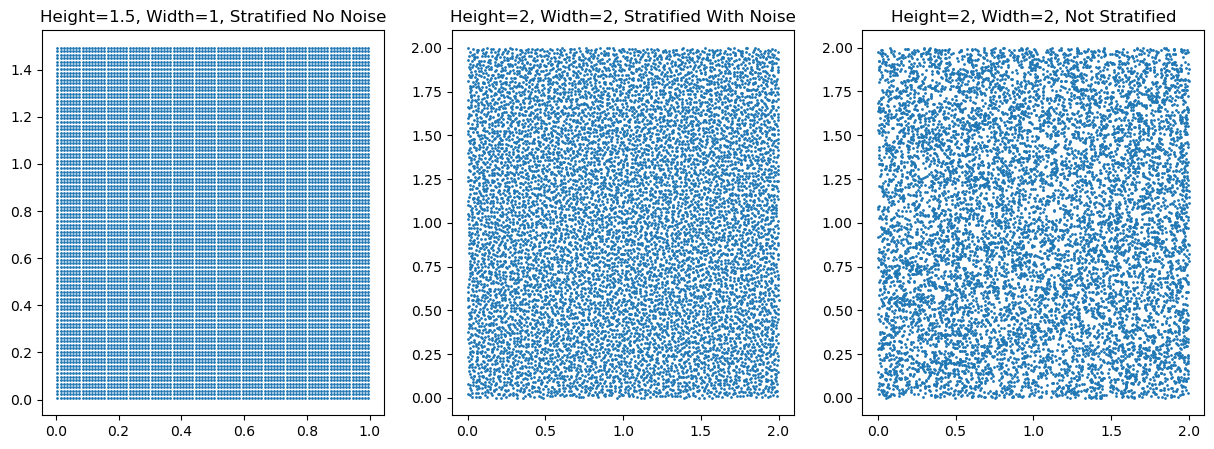

In [2]:
%autoreload 2
from infidictionary.domain_samplers import SquareSampler
import matplotlib.pyplot as plt

sampler1 = SquareSampler(stratified=True, height=1.5, width=1, add_noise=False)
coords = sampler1.sample(100)

sampler2 = SquareSampler(stratified=True, height=2, width=2, add_noise=True)
coords2 = sampler2.sample(100)

sampler3 = SquareSampler(stratified=False, height=2, width=2)
coords3 = sampler3.sample(100)

fig, axs = plt.subplots(1, 3, figsize=(15, 5))
axs[0].scatter(coords[:, 0], coords[:, 1], s=1)
axs[0].set_title('Height=1.5, Width=1, Stratified No Noise')
axs[1].scatter(coords2[:, 0], coords2[:, 1], s=1)
axs[1].set_title('Height=2, Width=2, Stratified With Noise')
axs[2].scatter(coords3[:, 0], coords3[:, 1], s=1)
axs[2].set_title('Height=2, Width=2, Not Stratified')
plt.show()

We also have a similar thing for samplers on a disk domain where 

$$\Omega = \{ x \mid \Vert x \Vert_2^2 \le r^2 \}.$$

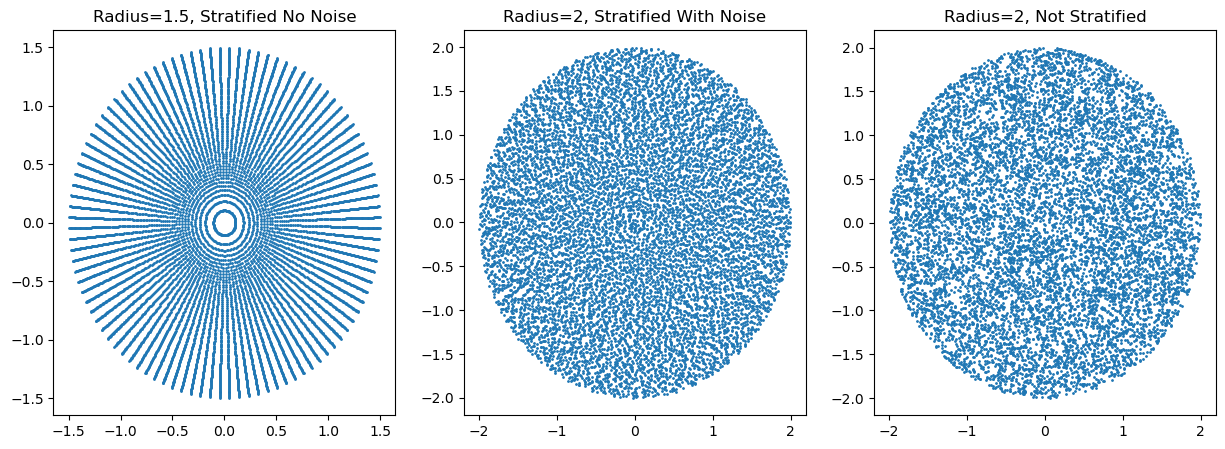

In [3]:
%autoreload 2
from infidictionary.domain_samplers import DiskSampler
import matplotlib.pyplot as plt

sampler1 = DiskSampler(stratified=True, radius=1.5, add_noise=False)
coords = sampler1.sample(100)

sampler2 = DiskSampler(stratified=True, radius=2, add_noise=True)
coords2 = sampler2.sample(100)

sampler3 = DiskSampler(stratified=False, radius=2, add_noise=False)
coords3 = sampler3.sample(100)

fig, axs = plt.subplots(1, 3, figsize=(15, 5))
axs[0].scatter(coords[:, 0], coords[:, 1], s=1)
axs[0].set_title('Radius=1.5, Stratified No Noise')
axs[1].scatter(coords2[:, 0], coords2[:, 1], s=1)
axs[1].set_title('Radius=2, Stratified With Noise')
axs[2].scatter(coords3[:, 0], coords3[:, 1], s=1)
axs[2].set_title('Radius=2, Not Stratified')
plt.show()

# Applying diffeomorphisms and pullback operations

In the following, we sample from a grid on $[0, 1]^2$ and try to map it to a disk with unit radius using different transformation mechansisms. In what follows, we sample a grid on a square and apply a diffeomorphism (either Shirly-Chiu or a simple Polar transformation) that maps from the square to the disk domain. Here, we visualize what happens to the grids after such transformations:

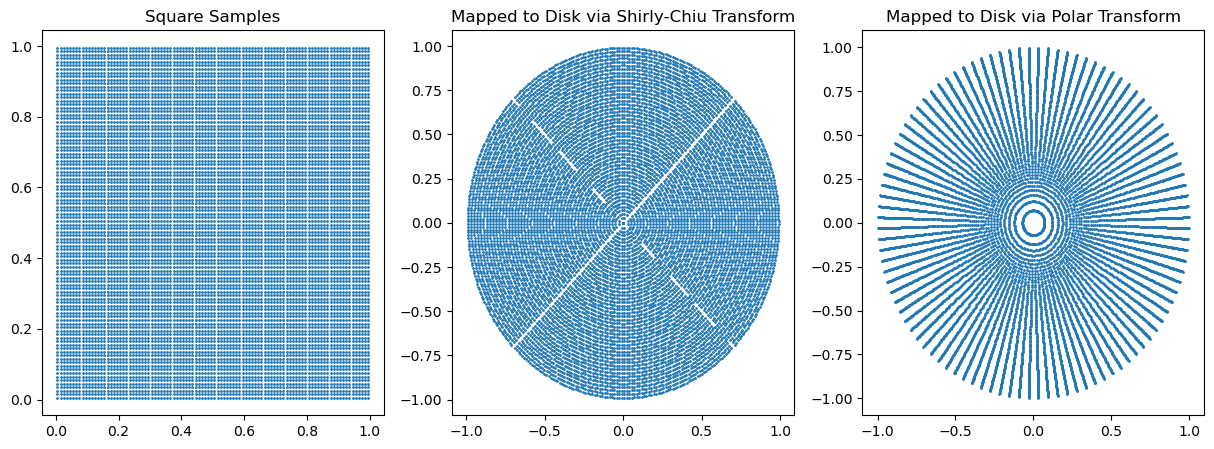

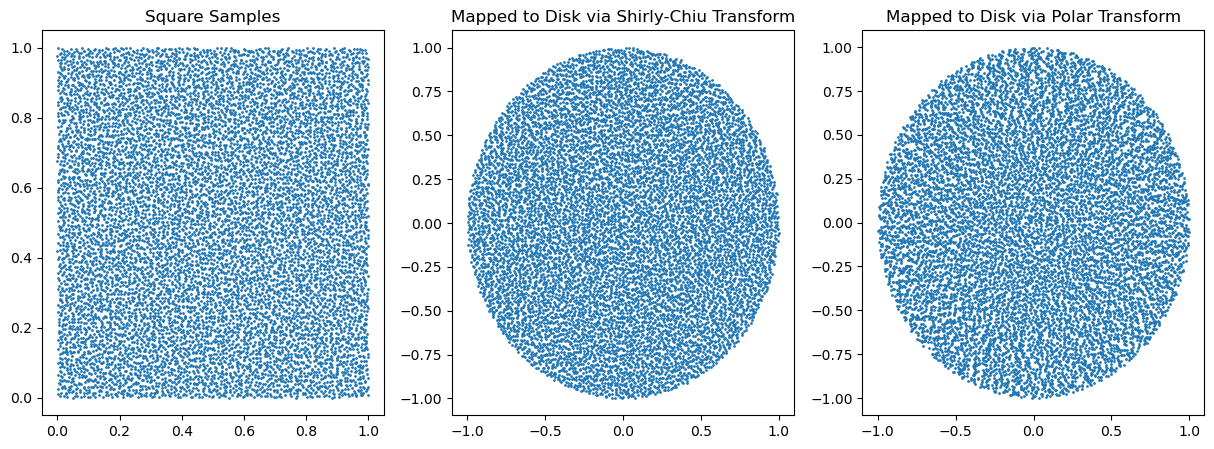

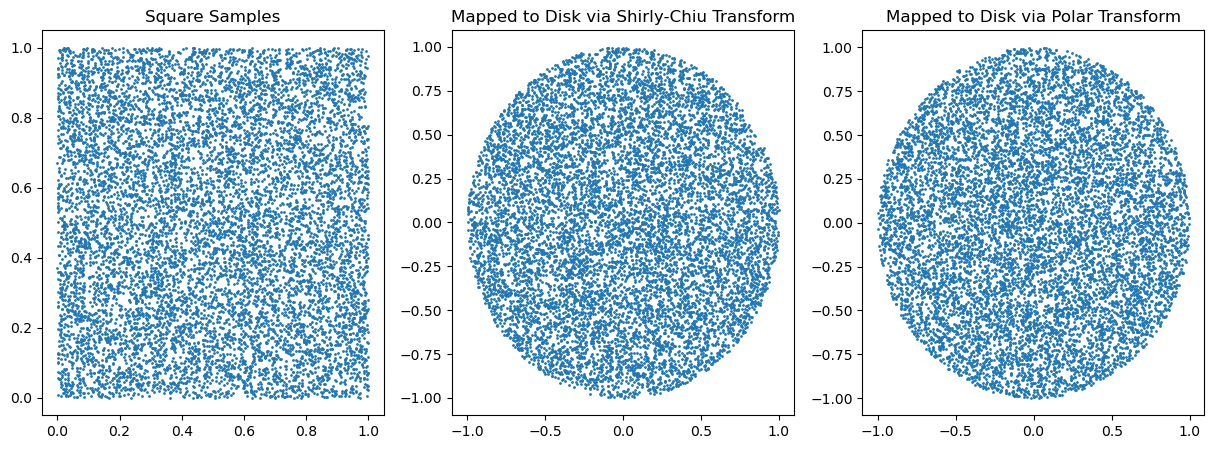

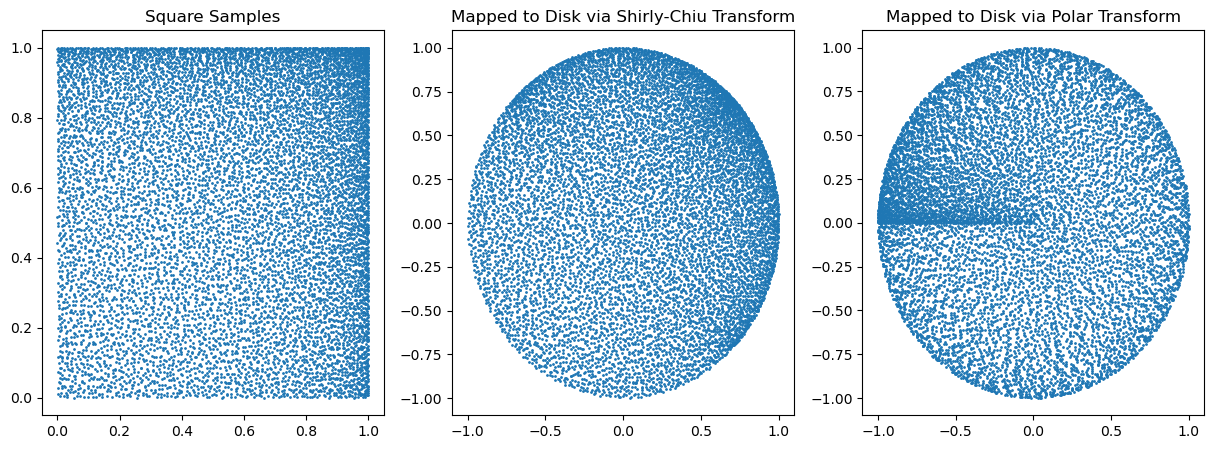

In [4]:
%autoreload 2
from infidictionary.diffeomorphisms import ShirlyChiu, PolarTransform, UnitSquareKumaraswamy
from infidictionary.domain_samplers import SquareSampler, DiskSampler


polar_mapper = PolarTransform()
shirly_chiu_mapper = ShirlyChiu()
N = 100
xy1 = SquareSampler(stratified=True, add_noise=False).sample(N)
xy2 = SquareSampler(stratified=True, add_noise=True).sample(N)
xy3 = SquareSampler(stratified=False, add_noise=False).sample(N)
xy4, _ = UnitSquareKumaraswamy(d=2,  a_min=0.1, b_min=0.5).forward(xy2)

for xy in [xy1, xy2, xy3, xy4]:
    xy_shirly, logabsdet = shirly_chiu_mapper.forward(xy)
    xy_polar, logabsdet_polar = polar_mapper.forward(xy)
    fig, axs = plt.subplots(1, 3, figsize=(15, 5))
    axs[0].scatter(xy[:, 0].detach().cpu(), xy[:, 1].detach().cpu(), s=1)
    axs[0].set_title(f'Square Samples')
    axs[1].scatter(xy_shirly[:, 0].detach().cpu(), xy_shirly[:,1].detach().cpu(), s=1)
    axs[1].set_title('Mapped to Disk via Shirly-Chiu Transform')
    axs[2].scatter(xy_polar[:, 0].detach().cpu(), xy_polar[:,1].detach().cpu(), s=1)
    axs[2].set_title('Mapped to Disk via Polar Transform')
    plt.show()

One thing we will use a lot are pulling back functions sampled on different domains onto a domain we can easily work with and do Fourier transforms on. Here, we visualize what happens to functions sampled on a disk domain when pulled back through the Lagrangian isometry we have formulated. We have used different diffeomorphism to show what happens to the function:

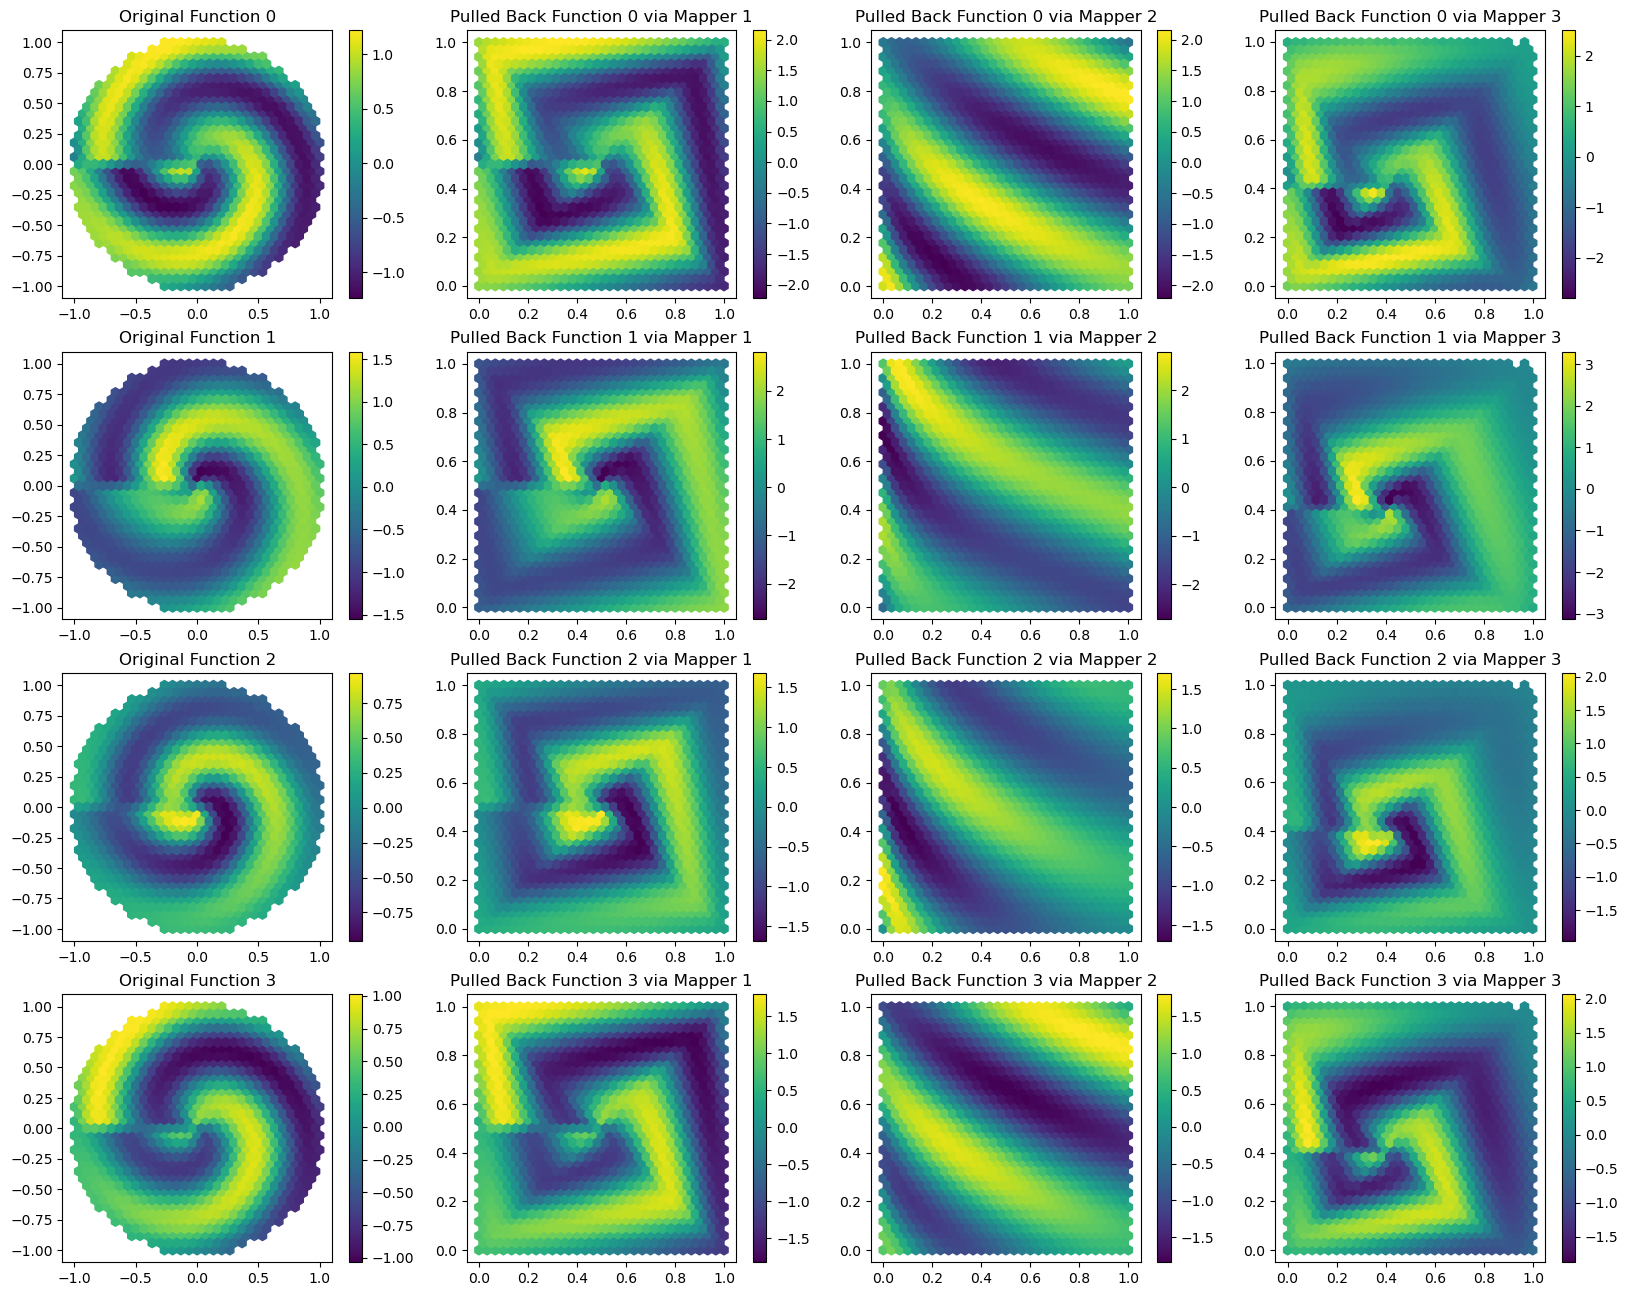

In [13]:
%autoreload 2 
from infidictionary.neural_isometries.lagrangian import LagrangianIsometry
from infidictionary.diffeomorphisms import ShirlyChiu, PolarTransform, ChainDiffeomorphism, UnitSquareKumaraswamy
from infidictionary.datasets import RandomBandpassGenerator

NUM_FUNCTIONS = 4
N = 200

bandpass_gen = RandomBandpassGenerator(
    radial=True,
    omega_lo=5,
    omega_hi=10,
    r_lo=0.5,
    r_hi=1.0,
    l_sin=5,
    l_cos=5,
    seed=1024,
)
sampler2 = DiskSampler(stratified=True, add_noise=True)
coords2 = sampler2.sample(N)
functions = bandpass_gen.get_batch(
    coords2,
    seeds=torch.arange(NUM_FUNCTIONS),
).unsqueeze(-1)

mapper1 = ChainDiffeomorphism(
    [
        ShirlyChiu(),
    ]
)
mapper2 = ChainDiffeomorphism(
    [
        PolarTransform(),
    ]
)
mapper3 = ChainDiffeomorphism(
    [
        UnitSquareKumaraswamy(d=2,  a_min=0.1, b_min=0.5),
        ShirlyChiu(),
    ]
) 

all_mappers = [mapper1, mapper2, mapper3]
pulled_back_functions = []
all_coords1 = []
all_logabsdets = []
for mapper in all_mappers:
    isometry = LagrangianIsometry(diffeomorphism=mapper)
    coords1, logabsdet, pulled_back_function = isometry.pullback(
        tgt_coords=coords2, 
        tgt_logabsdet=torch.zeros(coords2.shape[0], device=coords2.device), 
        tgt_field=functions
    )
    pulled_back_functions.append(pulled_back_function)
    all_coords1.append(coords1)
    all_logabsdets.append(logabsdet)

fig, axes = plt.subplots(NUM_FUNCTIONS, (1 + len(all_mappers)), figsize=((len(all_mappers) + 1) * 5, NUM_FUNCTIONS * 4))
for i in range(NUM_FUNCTIONS):
    ax = axes[i, 0]
    ax.hexbin(
        coords2[:, 0].detach().cpu(), coords2[:, 1].detach().cpu(), functions[i].detach().cpu(), gridsize=30, cmap='viridis'
    )
    plt.colorbar(ax.collections[0], ax=ax)
    ax.set_title(f'Original Function {i}')
    for mapper_idx, mapper in enumerate(all_mappers):
        isometry = LagrangianIsometry(diffeomorphism=mapper)
        ax = axes[i, 1 + mapper_idx]
        ax.hexbin(
            all_coords1[mapper_idx][:, 0].detach().cpu(), 
            all_coords1[mapper_idx][:, 1].detach().cpu(), 
            pulled_back_functions[mapper_idx][i].squeeze(-1).detach().cpu(), 
            gridsize=30, cmap='viridis',
        )
        ax.set_title(f'Pulled Back Function {i} via Mapper {mapper_idx + 1}')
        # color bar for each subplot
        plt.colorbar(ax.collections[0], ax=ax)
        
plt.show()


Interestingly, since the pullback is isometric (we have a volume correction term), the geometry of the functions does not change, this means that the pairwise inner products stay the same. In the following, we visualize the differences between the pairwise inner products before and after the transformations:

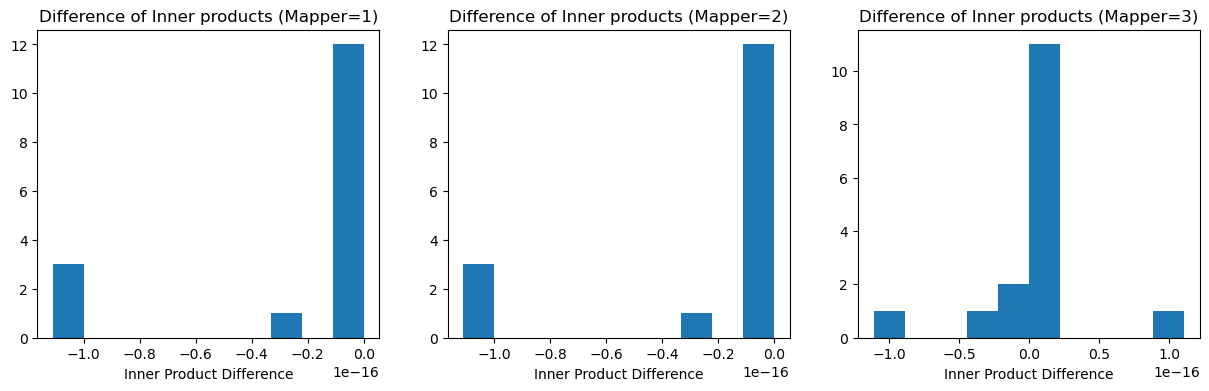

In [ ]:
%autoreload 2
from infidictionary.utils import pairwise_inner_product

fig, axes = plt.subplots(1, len(all_mappers), figsize=(len(all_mappers) * 5, 4))
# compute the inner products before and after pullback
inner_products_before = pairwise_inner_product(functions, functions)

for mapper_idx, mapper in enumerate(all_mappers):
    new_inner_products = pairwise_inner_product(pulled_back_functions[mapper_idx], pulled_back_functions[mapper_idx], logabsdet=all_logabsdets[mapper_idx])
    ax = axes[mapper_idx]
    diffs = inner_products_before - new_inner_products
    # plot histogram of diffs
    ax = axes[mapper_idx]
    ax.hist(diffs.flatten().detach().cpu())
    ax.set_xlabel('Inner Product Difference')
    ax.set_title(f'Difference of Inner products (Mapper={mapper_idx + 1})')
plt.show()